In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [12]:
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

fatal: destination path 'detectron2' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/detectron2


In [ ]:
!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'

In [3]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/Hugging Face/detectron2')

In [4]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [3]:
import detectron2
print(detectron2.__file__)
# It should show something like: /usr/local/lib/python3.10/dist-packages/detectron2/__init__.py

/usr/local/lib/python3.12/dist-packages/detectron2/__init__.py


In [ ]:
import torch
# Get the version of Torch and CUDA in current Colab session
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]

# Install the matching pre-built Detectron2 wheel
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/{CUDA_VERSION}/torch{TORCH_VERSION}/index.html

In [2]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

<Logger detectron2 (DEBUG)>

In [3]:
!git clone https://github.com/JIA-Lab-research/PanopticFCN.git
%cd PanopticFCN

fatal: destination path 'PanopticFCN' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/PanopticFCN


In [4]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/Hugging Face/PanopticFCN')

In [5]:
%cd /content/gdrive/MyDrive/Hugging Face/PanopticFCN

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/PanopticFCN


In [6]:
from panopticfcn.config import add_panopticfcn_config

In [7]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [8]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer, DefaultPredictor
from panopticfcn.config import add_panopticfcn_config

cfg = get_cfg()
add_panopticfcn_config(cfg)

# Use PanopticFCN with ResNet-50
cfg.merge_from_file("PanopticFCN/configs/PanopticFCN-R50-512-3x-FAST.yaml")
cfg.MODEL.WEIGHTS = "PanopticFCN/panoptic_fcn_r50_512_3x.pth"

predictor = DefaultPredictor(cfg)

[04/09 15:45:24 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from PanopticFCN/panoptic_fcn_r50_512_3x.pth ...


In [9]:
torch.cuda.empty_cache()

In [12]:
from PIL import Image
import io
import os
import torch
import numpy
import numpy as np
import cv2
import random
import math
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic_separated")

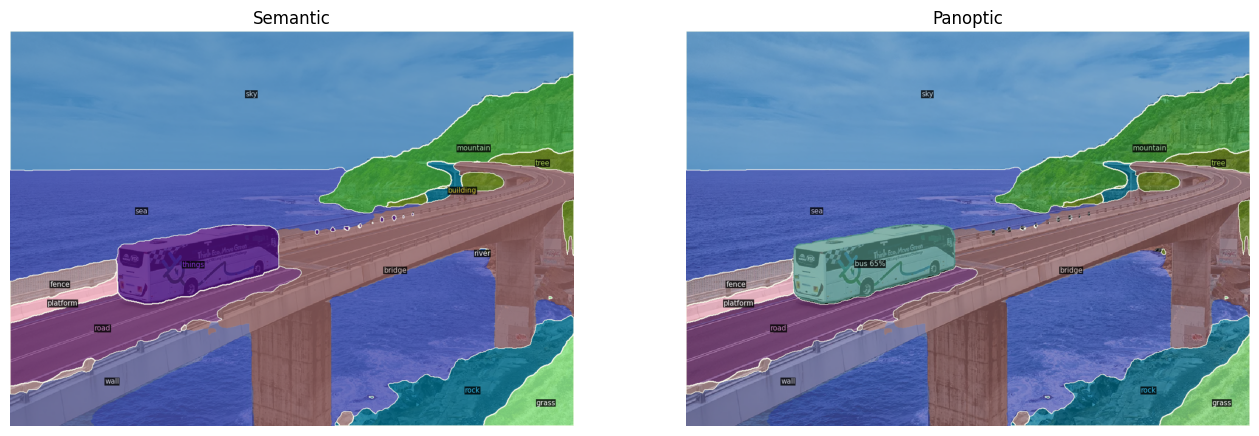

In [13]:
im = cv2.imread("/content/gdrive/MyDrive/Hugging Face/datasets/3d_tests/bus.jpg")
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()

# --- Display ---
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.title('Semantic')
plt.axis('off')
plt.imshow(semantic_result)

plt.subplot(1, 2, 2)
plt.title('Panoptic')
plt.axis('off')
plt.imshow(panoptic_result)
plt.show()

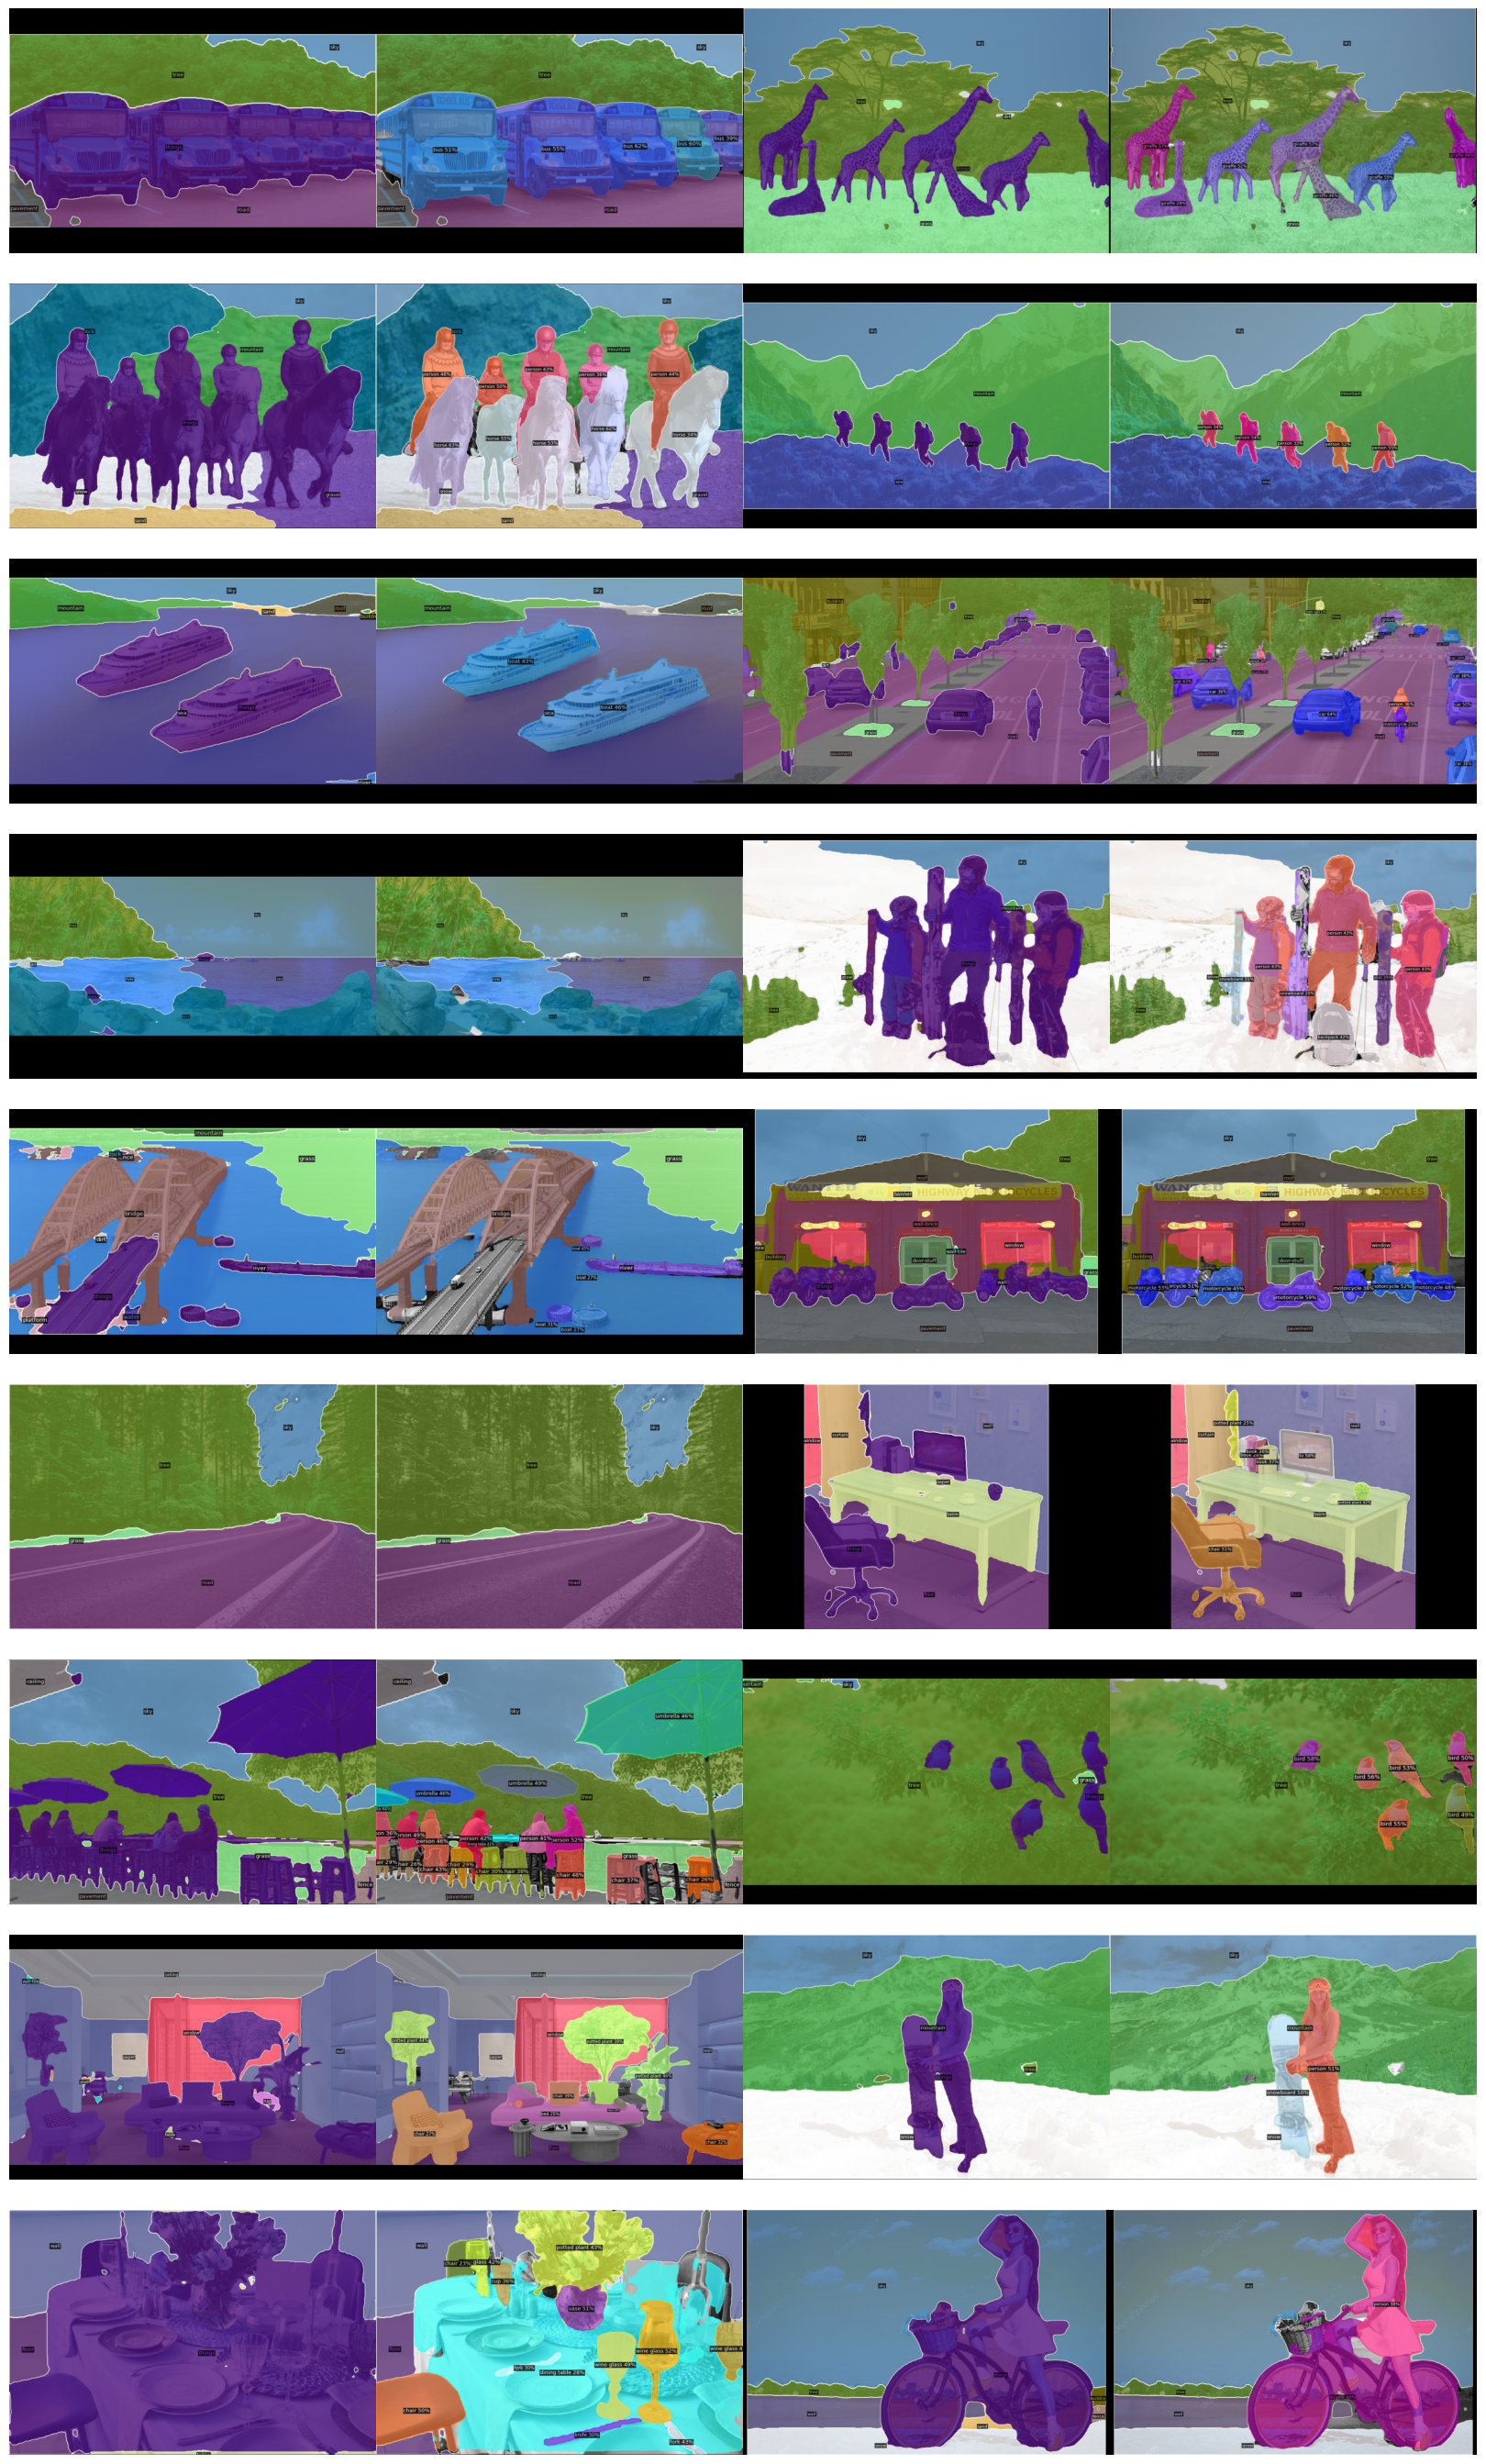

In [14]:
val_dir = "/content/gdrive/MyDrive/Hugging Face/datasets/panoptic-tests"
num_samples = 18

# --------------------------
# Collect images
# --------------------------
all_imgs = [f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
selected_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))
img_paths = [os.path.join(val_dir, fname) for fname in selected_imgs]

processed_imgs = []
img_sizes = []

for image_path in img_paths:
    # Load image
    image_pil = Image.open(image_path).convert("RGB")
    image_np = np.array(image_pil) # Convert PIL Image to NumPy array

    outputs = predictor(image_np)
    v = Visualizer(image_np[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
    panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
    v = Visualizer(image_np[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
    semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()

    processed_imgs.append((semantic_result, panoptic_result))
    img_sizes.append(image_np.shape[:2])  # (height, width)

# --------------------------
# Prepare for grid plot
# --------------------------

cols = 4  # 2 images x 2 visuals = 4 subplots per row
rows = (len(processed_imgs) + 1) // 2  # 2 images per row

plt.figure(figsize=(4 * cols, 3 * rows))

# Target display size for each grid cell
target_height = 720
target_width = 1080

for idx, (img1, img2) in enumerate(processed_imgs):
    for view_idx, view in enumerate([img1, img2]):
        h, w = view.shape[:2]

        # Scale keeping aspect ratio
        scale = min(target_width / w, target_height / h)
        new_w, new_h = int(w * scale), int(h * scale)
        resized = cv2.resize(view, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

        # Pad to target size
        top = (target_height - new_h) // 2
        bottom = target_height - new_h - top
        left = (target_width - new_w) // 2
        right = target_width - new_w - left
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                    borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0))

        plot_idx = idx * 2 + view_idx + 1
        plt.subplot(rows, cols, plot_idx)
        plt.imshow(padded)
        plt.axis('off')

plt.tight_layout(pad=0)           # removes padding around the whole figure
plt.subplots_adjust(wspace=0, hspace=0)  # removes spacing between cells
plt.show()